In [ ]:
!pip install skan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
#Cek link
import os

# Path yang mau dicek
path = "/content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi"

# Cek apakah path ada
if os.path.exists(path):
    print(f"✅ Path ditemukan: {path}")
    # Kalau mau lihat isi foldernya
    print("Isi folder:")
    print(os.listdir(path))
else:
    print(f"❌ Path tidak ditemukan: {path}")

✅ Path ditemukan: /content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi
Isi folder:
['crop_2.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


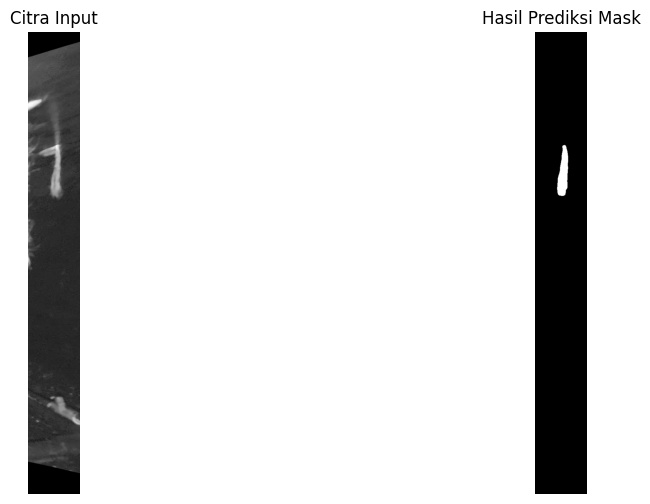

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. Load model
model = load_model("/content/gdrive/MyDrive/Tugas_Akhir/model_u-net_terpisah_rev.keras")

# 2. Load citra grayscal
img_path = "/content/gdrive/MyDrive/Tugas_Akhir/Validasi/crop_10.jpg"  # ganti dengan path gambar Anda
IMG_HEIGHT = 1440
IMG_WIDTH = 160

# Baca citra dalam mode grayscale
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Gambar {img_path} tidak ditemukan!")

# Resize ke ukuran input model
input_img = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

# Normalisasi (0-1)
input_img = input_img / 255.0

# Tambahkan dimensi channel dan batch -> (1, H, W, 1)
input_img = np.expand_dims(input_img, axis=-1)
input_img = np.expand_dims(input_img, axis=0)

# 3. Prediksi dengan mode
pred_mask = model.predict(input_img)

if pred_mask.shape[-1] > 1:
    # multiclass segmentation
    pred_mask = np.argmax(pred_mask, axis=-1)
else:
    # binary segmentation
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

pred_mask = np.squeeze(pred_mask)

# 4. Tampilkan hasi
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Citra Input")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Hasil Prediksi Mask")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
# simpan hasil prediksi
output_path = "/content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi/crop_10.jpg"  # bisa diganti ke .jpg
cv2.imwrite(output_path, pred_mask * 255)  # kali 255 biar putih-hitam terlihat jelas
print(f"Hasil mask disimpan di: {output_path}")

Hasil mask disimpan di: /content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi/crop_10.jpg


Panjang akar (piksel): 1510
Panjang akar (cm)    : 81.62


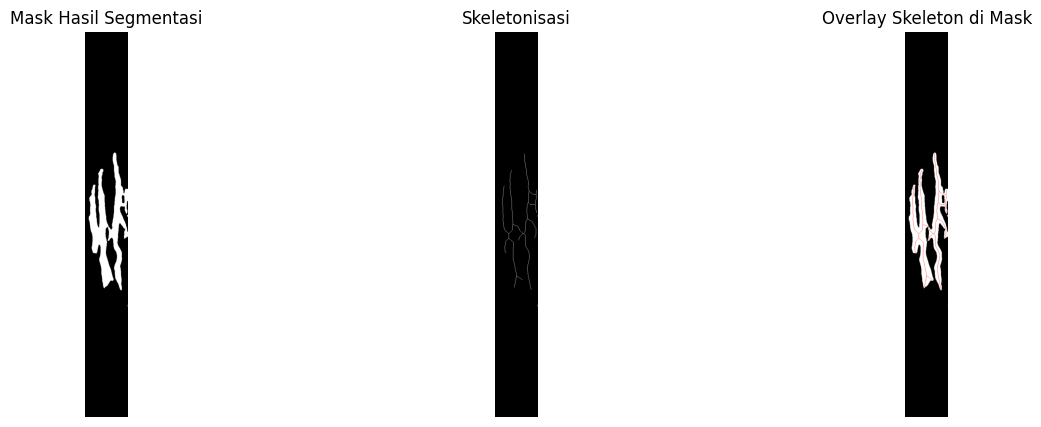

In [ ]:
# skeleton (tidak dipakai)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# --- 1. Load mask hasil prediksi ---
mask_path = "/content/gdrive/MyDrive/Tugas_Akhir/Citra/prediksi/koreksi_302.jpg"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

if mask is None:
    raise FileNotFoundError(f"Gambar {mask_path} tidak ditemukan!")

# Pastikan binary (0/1)
_, binary = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

# --- 2. Skeletonization ---
skeleton = skeletonize(binary).astype(np.uint8)

# --- 3. Hitung panjang akar (jumlah piksel skeleton) ---
root_length_px = np.sum(skeleton)

# --- 4. Konversi ke cm ---
# Misal hasil kalibrasi: 100 piksel = 1 cm
pixels_per_cm = 18.5   # <<-- ganti sesuai hasil kalibrasi Anda
root_length_cm = root_length_px / pixels_per_cm

print(f"Panjang akar (piksel): {root_length_px}")
print(f"Panjang akar (cm)    : {root_length_cm:.2f}")

# --- 5. Tampilkan hasil ---
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Mask Hasil Segmentasi")
plt.imshow(binary, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Skeletonisasi")
plt.imshow(skeleton, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay Skeleton di Mask")
overlay = cv2.cvtColor(binary*255, cv2.COLOR_GRAY2RGB)
overlay[skeleton==1] = [255,0,0]  # skeleton merah
plt.imshow(overlay)
plt.axis("off")

plt.show()


/tmp/ipython-input-1844621922.py:28: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  branch_data = summarize(sk)


===== Hasil Analisis Skeleton =====
Jumlah cabang akar     : 24
Total panjang akar (cm): 117.51
Akar terpanjang (cm)   : 16.20


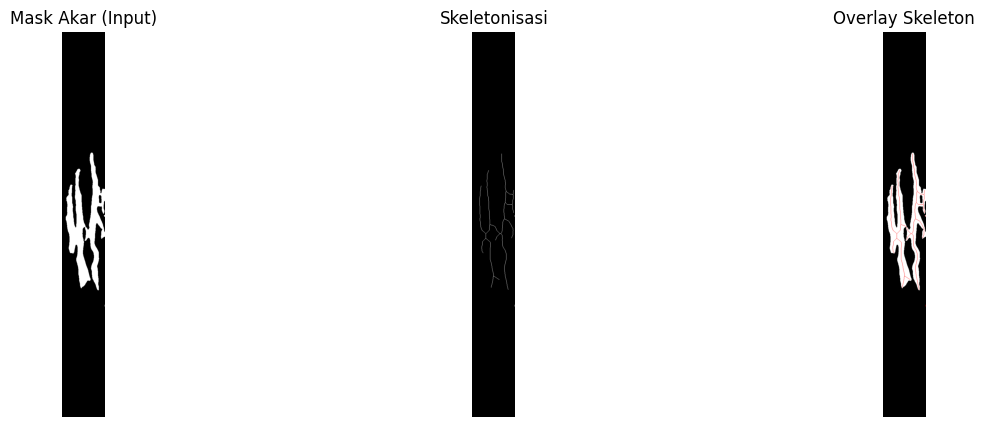

Data cabang akar disimpan di branch_analysis.csv


In [ ]:
# gabungan skeleton dan graph analisys (tidak dipakai)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan import Skeleton, summarize

# --- 1. Load hasil prediksi U-Net (mask biner) ---
mask_path = "/content/gdrive/MyDrive/Tugas_Akhir/Citra/prediksi/koreksi_302 (4).jpg"   # file hasil prediksi U-Net
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise FileNotFoundError(f"Gambar {mask_path} tidak ditemukan!")

# Pastikan biner 0/1
_, binary_root = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

# --- 2. Skeletonisasi ---
skeleton = skeletonize(binary_root).astype(np.uint8)

# --- 3. Konversi ke graph dengan skan ---
# Misalnya hasil kalibrasi: 100 piksel = 1 cm
pixels_per_cm = 14
cm_per_pixel = 1.0 / pixels_per_cm

sk = Skeleton(skeleton, spacing=cm_per_pixel)

# --- 4. Ringkasan cabang (branch analysis) ---
branch_data = summarize(sk)

# Total panjang semua akar (cm)
total_length_cm = branch_data["branch-distance"].sum()

# Panjang cabang terpanjang (bisa dianggap akar utama)
main_root_cm = branch_data["branch-distance"].max()

print("===== Hasil Analisis Skeleton =====")
print(f"Jumlah cabang akar     : {len(branch_data)}")
print(f"Total panjang akar (cm): {total_length_cm:.2f}")
print(f"Akar terpanjang (cm)   : {main_root_cm:.2f}")

# --- 5. Visualisasi ---
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Mask Akar (Input)")
plt.imshow(binary_root, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Skeletonisasi")
plt.imshow(skeleton, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay Skeleton")
overlay = cv2.cvtColor(binary_root*255, cv2.COLOR_GRAY2RGB)
overlay[skeleton==1] = [255,0,0]  # skeleton merah
plt.imshow(overlay)
plt.axis("off")

plt.show()

# --- 6. (Opsional) Simpan hasil analisis ke CSV ---
branch_data.to_csv("branch_analysis.csv", index=False)
print("Data cabang akar disimpan di branch_analysis.csv")



In [ ]:
# (tidak dipakai)
import cv2
import numpy as np
from skimage.morphology import skeletonize
from skan import csr, summarise
import networkx as nx

# === 1. Baca mask hasil U-Net ===
mask = cv2.imread("/content/gdrive/MyDrive/Tugas_Akhir/Citra/prediksi/koreksi_302 (3).jpg" , cv2.IMREAD_GRAYSCALE)
_, binary_root = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

# === 2. Skeletonization ===
skeleton = skeletonize(binary_root).astype(np.uint8)

# Skeleton graph
result = csr.skeleton_to_csgraph(skeleton)

if len(result) == 2:
    adjacency, coordinates = result
    degrees = None
elif len(result) == 3:
    adjacency, coordinates, degrees = result
else:
    raise ValueError("Format keluaran skeleton_to_csgraph tidak dikenali")

# Buat graph dari adjacency matrix
graph = nx.Graph(adjacency)

# === 4. Cari dua endpoint terjauh ===
# Endpoint = node dengan degree == 1
endpoints = [n for n in graph.nodes if graph.degree[n] == 1]

max_dist = 0
longest_path = []
for i in range(len(endpoints)):
    for j in range(i+1, len(endpoints)):
        try:
            path = nx.shortest_path(graph, endpoints[i], endpoints[j])
            dist = nx.shortest_path_length(graph, endpoints[i], endpoints[j], weight=None)
            if dist > max_dist:
                max_dist = dist
                longest_path = path
        except nx.NetworkXNoPath:
            continue

# === 5. Hitung panjang dalam cm (misal 50 px = 1 cm) ===
px_per_cm = 50
main_root_length_cm = max_dist / px_per_cm

print(f"Panjang akar utama: {main_root_length_cm:.2f} cm")

# === 6. Hitung total panjang semua cabang ===
if degrees is not None:
    branch_data = summarise(adjacency, coordinates, degrees)
else:
    branch_data = summarise(adjacency, coordinates)
total_length_px = branch_data["branch-distance"].sum()
secondary_roots_length_cm = (total_length_px - max_dist) / px_per_cm

print(f"Total panjang cabang (akar sekunder): {secondary_roots_length_cm:.2f} cm")
print(f"Total panjang semua akar: {(total_length_px/px_per_cm):.2f} cm")


ImportError: cannot import name 'summarise' from 'skan' (/usr/local/lib/python3.11/dist-packages/skan/__init__.py)

In [ ]:
import cv2
import numpy as np

# Path gambar hasil prediksi U-Net (mask hitam putih)
image_path = "/content/gdrive/MyDrive/Tugas_Akhir/Citra/prediksi/koreksi_302 (1).jpg"

# Rasio skala (misalnya 50 piksel = 1 cm)
PIXELS_PER_CM = 18.5

# Baca gambar
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Threshold biner (jaga-jaga kalau masih grayscale)
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Cari kontur
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Pilih kontur terbesar (akar utama)
cnt = max(contours, key=cv2.contourArea)

# Cari titik paling atas (min Y) dan paling bawah (max Y)
topmost = tuple(cnt[cnt[:,:,1].argmin()][0])     # (x, y) dengan y minimum
bottommost = tuple(cnt[cnt[:,:,1].argmax()][0]) # (x, y) dengan y maksimum

# Hitung jarak vertikal dalam piksel
vertical_distance_px = abs(bottommost[1] - topmost[1])

# Konversi ke cm
vertical_distance_cm = vertical_distance_px / PIXELS_PER_CM

print("Titik paling atas:", topmost)
print("Titik paling bawah:", bottommost)
print(f"Jarak vertikal (px): {vertical_distance_px}")
print(f"Jarak vertikal (cm): {vertical_distance_cm:.2f} cm")

# Visualisasi
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(output, topmost, 5, (0,0,255), -1)     # merah = atas
cv2.circle(output, bottommost, 5, (255,0,0), -1)  # biru = bawah

cv2.imwrite("/content/gdrive/MyDrive/Tugas_Akhir/Citra/prediksi/titik/koreksi_302(1).jpg", output)


Titik paling atas: (np.int32(67), np.int32(526))
Titik paling bawah: (np.int32(108), np.int32(899))
Jarak vertikal (px): 373
Jarak vertikal (cm): 20.16 cm


True

In [ ]:
import cv2
import numpy as np

# Path gambar hasil prediksi U-Net (mask hitam putih)
image_path = "/content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi/crop_5.jpg"

# Rasio skala (misalnya 18.5 piksel = 1 cm)
PIXELS_PER_CM = 30.8

# Baca gambar
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Threshold biner
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Cari kontur
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter kontur berdasarkan posisi centroid di antara x=75 dan x=85
selected_contours = []
for cnt in contours:
    M = cv2.moments(cnt)
    if M["m00"] > 0:  # hindari divisi nol
        cx = int(M["m10"] / M["m00"])  # koordinat x centroid
        if 70 <= cx <= 90:
            selected_contours.append(cnt)

if len(selected_contours) == 0:
    raise ValueError("Tidak ada kontur dengan centroid di antara x=75–85")

# Jika lebih dari satu kontur ditemukan, bisa pilih yang terpanjang (opsional)
cnt = max(selected_contours, key=cv2.contourArea)

# Cari titik paling atas (min Y) dan paling bawah (max Y)
topmost = tuple(cnt[cnt[:,:,1].argmin()][0])     # (x, y) dengan y minimum
bottommost = tuple(cnt[cnt[:,:,1].argmax()][0]) # (x, y) dengan y maksimum

# Hitung jarak vertikal dalam piksel
vertical_distance_px = abs(bottommost[1] - topmost[1])

# Konversi ke cm
vertical_distance_cm = vertical_distance_px / PIXELS_PER_CM

print("Titik paling atas:", topmost)
print("Titik paling bawah:", bottommost)
print(f"Jarak vertikal (px): {vertical_distance_px}")
print(f"Jarak vertikal (cm): {vertical_distance_cm:.2f} cm")

# Visualisasi
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(output, topmost, 5, (0,0,255), -1)     # merah = atas
cv2.circle(output, bottommost, 5, (255,0,0), -1)  # biru = bawah
cv2.drawContours(output, [cnt], -1, (0,255,0), 2) # kontur terpilih (hijau)

cv2.imwrite("/content/gdrive/MyDrive/Tugas_Akhir/Validasi/titik/akar3.jpg", output)


Titik paling atas: (np.int32(72), np.int32(425))
Titik paling bawah: (np.int32(79), np.int32(628))
Jarak vertikal (px): 203
Jarak vertikal (cm): 6.59 cm


True

In [ ]:
#ini yang fix
import cv2
import numpy as np

# Path gambar hasil prediksi U-Net (mask hitam putih)
image_path = "/content/gdrive/MyDrive/Tugas_Akhir/Validasi/prediksi/crop_10.jpg"

# Rasio skala (misalnya 18.5 piksel = 1 cm)
a3 = 29
a4 = 18
a5 = 13.5
a6 = 11.5
PIXELS_PER_CM = a4
# Baca gambar
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Threshold biner
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Cari kontur
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter kontur berdasarkan bounding box (harus memotong antara x=75–85)
selected_contours = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if (x <= 85) and (x + w >= 75):
        # bounding box melintasi area x=75–85
        selected_contours.append(cnt)

if len(selected_contours) == 0:
    raise ValueError("Tidak ada kontur dengan bounding box yang memotong x=75–85")

# Jika lebih dari satu, pilih yang terbesar
cnt = max(selected_contours, key=cv2.contourArea)

# Cari titik paling atas (min Y) dan paling bawah (max Y)
topmost = tuple(cnt[cnt[:,:,1].argmin()][0])     # (x, y) dengan y minimum
bottommost = tuple(cnt[cnt[:,:,1].argmax()][0]) # (x, y) dengan y maksimum

# Hitung jarak vertikal dalam piksel
vertical_distance_px = abs(bottommost[1] - topmost[1])

# Konversi ke cm
vertical_distance_cm = vertical_distance_px / PIXELS_PER_CM

print("Titik paling atas:", topmost)
print("Titik paling bawah:", bottommost)
print(f"Jarak vertikal (px): {vertical_distance_px}")
print(f"Jarak vertikal (cm): {vertical_distance_cm:.2f} cm")

# Visualisasi
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(output, topmost, 5, (0,0,255), -1)     # merah = atas
cv2.circle(output, bottommost, 5, (255,0,0), -1)  # biru = bawah
cv2.drawContours(output, [cnt], -1, (0,255,0), 2) # hijau = kontur terpilih

cv2.imwrite("/content/gdrive/MyDrive/Tugas_Akhir/Validasi/titik/akarcoba1.jpg", output)

Titik paling atas: (np.int32(90), np.int32(352))
Titik paling bawah: (np.int32(80), np.int32(510))
Jarak vertikal (px): 158
Jarak vertikal (cm): 8.78 cm


True